In [1]:
pip install h5py rasterio numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Path to your file
file_path = r"D:\NEON_refl-surf-dir-ortho-mosaic\NEON.D01.HARV.DP3.30006.001.2014-06.basic.20260417T112535Z.RELEASE-2026\NEON_D01_HARV_DP3_731000_4711000_reflectance.h5"

# Open file
hdf5_file = h5py.File(file_path, 'r')

# Explore structure
print(list(hdf5_file.keys()))

['HARV']


In [4]:
# Navigate (depends on file structure)
refl = hdf5_file['HARV']['Reflectance']['Reflectance_Data']

# Convert to numpy
refl_array = np.array(refl)

print(list(hdf5_file.keys()))

['HARV']


In [5]:
wavelength = hdf5_file['HARV']['Reflectance']['Metadata']['Spectral_Data']['Wavelength']
wavelength = np.array(wavelength)

In [13]:
# Step 1: pick pixel correctly
pixel_spectrum = refl_array[100, 100, :]

In [14]:
# Step 2: check shapes
print("Wavelength:", wavelength.shape)
print("Pixel spectrum:", pixel_spectrum.shape)

Wavelength: (426,)
Pixel spectrum: (426,)


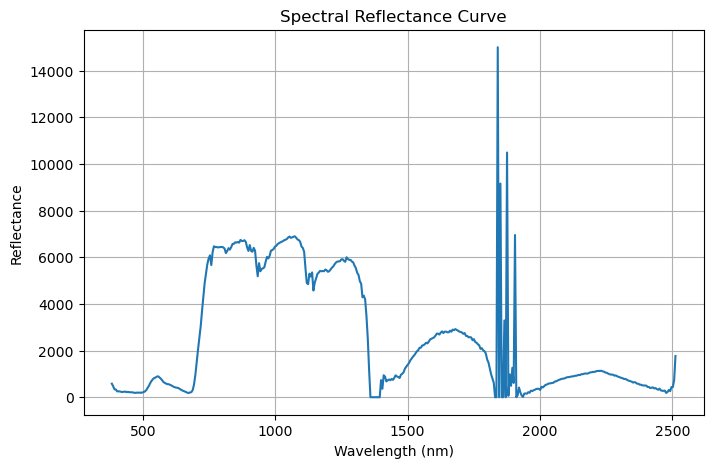

In [15]:
# Step 3: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(wavelength, pixel_spectrum)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Reflectance Curve")
plt.grid()

plt.show()

In [19]:
import matplotlib.pyplot as plt

# Remove noisy region (recommended)
valid_idx = (wavelength > 400) & (wavelength < 1800)

wavelength_clean = wavelength[valid_idx]
pixel_clean = pixel_spectrum[valid_idx]

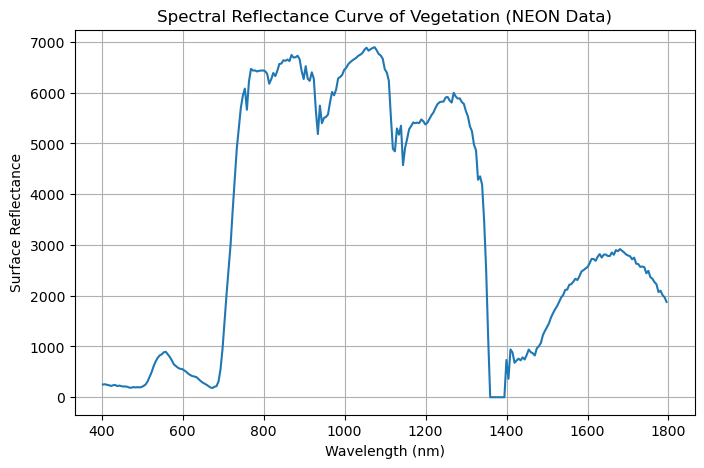

In [22]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(wavelength_clean, pixel_clean)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Surface Reflectance")
plt.title("Spectral Reflectance Curve of Vegetation (NEON Data)")
plt.grid()

In [1]:
# 1. Import Libraries
# ===============================
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2. Load NEON Hyperspectral Data
# ===============================
file_path = r"D:\NEON_refl-surf-dir-ortho-mosaic\NEON.D01.HARV.DP3.30006.001.2014-06.basic.20260417T112535Z.RELEASE-2026\NEON_D01_HARV_DP3_731000_4711000_reflectance.h5"

f = h5py.File(file_path, 'r')

In [4]:
# Navigate inside HDF5 structure
reflectance = f['HARV']['Reflectance']['Reflectance_Data'][:]
wavelengths = f['HARV']['Reflectance']['Metadata']['Spectral_Data']['Wavelength'][:]
print("Shape:", reflectance.shape)

Shape: (1000, 1000, 426)


In [5]:
# 3. Remove NoData values
reflectance = reflectance.astype(float)
reflectance[reflectance == -9999] = np.nan

In [6]:
# 4. Select RGB Bands
# Approx wavelengths for RGB
red_band = np.argmin(np.abs(wavelengths - 660))
green_band = np.argmin(np.abs(wavelengths - 550))
blue_band = np.argmin(np.abs(wavelengths - 470))

In [7]:
# Extract bands
R = reflectance[:, :, red_band]
G = reflectance[:, :, green_band]
B = reflectance[:, :, blue_band]

In [14]:
# 5. Normalize Bands (IMPORTANT)
def stretch(band):
    p2, p98 = np.nanpercentile(band, (2, 98))   # stretch between 2% and 98%
    band = np.clip((band - p2) / (p98 - p2), 0, 1)
    return band

R = stretch(R)
G = stretch(G)
B = stretch(B)

In [16]:
# Stack RGB
rgb = np.dstack((R, G, B))
gamma = 0.5   # <1 makes image brighter

rgb = np.power(rgb, gamma)

In [17]:
# 6. False Color (NIR, Red, Green)
nir_band = np.argmin(np.abs(wavelengths - 800))
NIR = normalize(reflectance[:, :, nir_band])
false_color = np.dstack((NIR, R, G))
NIR = stretch(NIR)

false_color = np.dstack((NIR, R, G))
false_color = np.power(false_color, gamma)

In [19]:
# Get exact wavelengths used
red_wl = wavelengths[red_band]
green_wl = wavelengths[green_band]
blue_wl = wavelengths[blue_band]

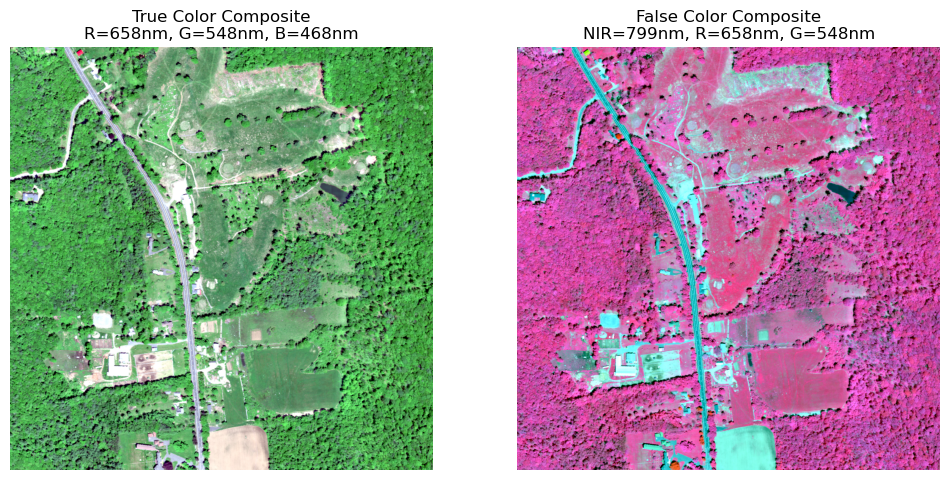

In [20]:
# 7. Plot Images
plt.figure(figsize=(12,6))

# True RGB
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(f"True Color Composite\nR={red_wl:.0f}nm, G={green_wl:.0f}nm, B={blue_wl:.0f}nm")
plt.axis('off')

# False Color
plt.subplot(1,2,2)
plt.imshow(false_color)
plt.title(f"False Color Composite\nNIR={wavelengths[nir_band]:.0f}nm, R={red_wl:.0f}nm, G={green_wl:.0f}nm")
plt.axis('off')

plt.show()